# Perceptrón: implementación y por qué funciona

En este cuaderno se implementa el algoritmo de aprendizaje del perceptrón (PLA), se resuelven los ejercicios 1.2 y 1.3, y se responden tres preguntas: si el algoritmo encuentra parámetros que separan los datos, si termina en un número finito de pasos, y por qué funciona.

## El modelo del perceptrón

Cada dato es un vector $x = (x_1,\dots,x_d)$ y su etiqueta es $y \in \{-1,+1\}$. El perceptrón clasifica con

$$h(x) = \operatorname{sign}(w^\top x),$$

donde para incluir el umbral (sesgo) se agrega una coordenada constante $x_0 = 1$, de modo que $w_0$ hace de umbral. La predicción es $+1$ o $-1$ según de qué lado del hiperplano $w^\top x = 0$ caiga el punto.

El algoritmo empieza con $w = 0$ y, mientras haya algún punto mal clasificado, lo corrige con la regla de actualización (ecuación 1.3 del libro):

$$w(t+1) = w(t) + y(t)\,x(t).$$

## Implementación del PLA

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def agrega_sesgo(X):
    # agrega la columna x0 = 1 para el umbral
    return np.hstack([np.ones((X.shape[0], 1)), X])

def pla(X, y, max_iter=100000, seed=0):
    Xa = agrega_sesgo(X)
    w = np.zeros(Xa.shape[1])
    historia = [w.copy()]
    actualizaciones = 0
    rng = np.random.default_rng(seed)
    for _ in range(max_iter):
        pred = np.sign(Xa @ w)
        pred[pred == 0] = -1
        mal = np.where(pred != y)[0]          # puntos mal clasificados
        if len(mal) == 0:                     # ya no hay errores: termina
            break
        i = rng.choice(mal)                   # se elige uno y se corrige
        w = w + y[i] * Xa[i]                   # regla (1.3)
        actualizaciones += 1
        historia.append(w.copy())
    return w, actualizaciones, historia

## Datos separables y ejecución

Se genera un conjunto de datos linealmente separable en 2D a partir de una recta verdadera, dejando una franja libre alrededor para que exista margen.

In [2]:
def genera_datos_separables(m=60, seed=1):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-5, 5, size=(m, 2))
    # recta verdadera: x2 = 0.5 x1 + 1 ; se descarta una franja para dejar margen
    dist = X[:, 1] - (0.5 * X[:, 0] + 1)
    mask = np.abs(dist) > 0.8
    X = X[mask]
    y = np.where(X[:, 1] > 0.5 * X[:, 0] + 1, 1, -1)
    return X, y

X, y = genera_datos_separables()
w, actualizaciones, historia = pla(X, y)

pred = np.sign(agrega_sesgo(X) @ w); pred[pred == 0] = -1
print("número de puntos:", len(X))
print("actualizaciones hasta converger:", actualizaciones)
print("errores al final:", int((pred != y).sum()))
print("w encontrado:", w)

número de puntos: 55
actualizaciones hasta converger: 6
errores al final: 0
w encontrado: [-2.         -3.71947526  7.79515324]


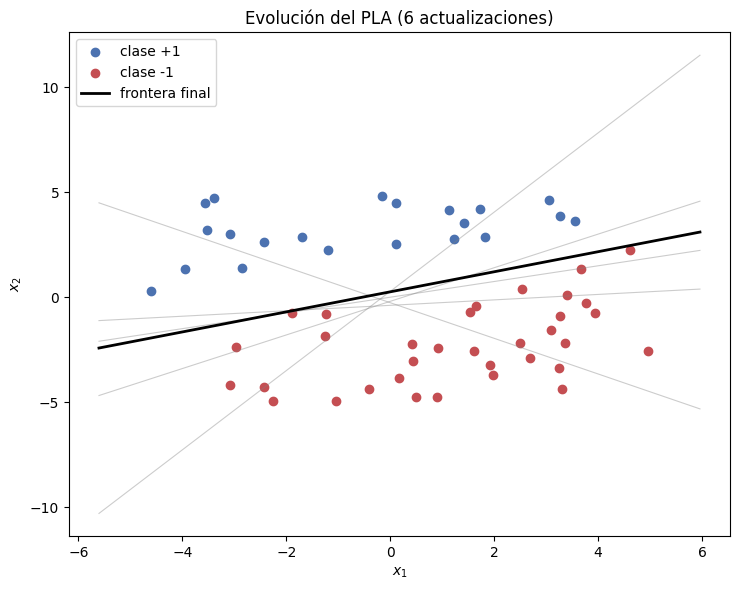

In [3]:
def frontera(ax, w, xr, **kw):
    # dibuja la recta w0 + w1 x1 + w2 x2 = 0
    if abs(w[2]) > 1e-9:
        xs = np.array(xr)
        ys = -(w[0] + w[1] * xs) / w[2]
        ax.plot(xs, ys, **kw)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#4C72B0", label="clase +1")
ax.scatter(X[y == -1, 0], X[y == -1, 1], c="#C44E52", label="clase -1")
xr = (X[:, 0].min() - 1, X[:, 0].max() + 1)

# fronteras intermedias (gris) y final (negra)
for wk in historia[1:-1]:
    frontera(ax, wk, xr, color="gray", lw=0.8, alpha=0.4)
frontera(ax, historia[-1], xr, color="k", lw=2, label="frontera final")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title(f"Evolución del PLA ({actualizaciones} actualizaciones)")
ax.legend(loc="best"); plt.tight_layout(); plt.show()

Las rectas grises son los hiperplanos intermedios y la negra es el que separa por completo las dos clases. Cada actualización reorienta la frontera hasta que no queda ningún punto mal clasificado.

## Ejercicio 1.2

Se usa un perceptrón para detectar spam. Cada correo se representa por la frecuencia de aparición de ciertas palabras clave, y la salida es $+1$ si el mensaje se considera spam.

**(a) Palabras clave con peso positivo grande.** Serían palabras muy asociadas al spam, cuya presencia empuja la salida hacia $+1$: por ejemplo "gratis", "premio", "ganador", "oferta", "descuento", "viagra", "dinero", "urgente", "haz clic". Mientras más aparezcan, mayor es $w^\top x$ y más probable que el mensaje se marque como spam.

**(b) Palabras clave con peso negativo.** Serían palabras propias de correos legítimos, que empujan la salida hacia $-1$: por ejemplo el nombre del destinatario, términos del trabajo o del contexto habitual ("reunión", "informe", "adjunto", "proyecto"). Su presencia baja $w^\top x$ y aleja el mensaje de la clasificación de spam.

**(c) Parámetro que controla cuántos mensajes fronterizos se marcan como spam.** Es el umbral, es decir el peso del sesgo $w_0$ (la coordenada constante $x_0=1$). El perceptrón decide spam cuando $w^\top x > 0$, o sea cuando la suma ponderada de palabras supera $-w_0$. Subir o bajar $w_0$ mueve ese umbral: un $w_0$ mayor hace que más mensajes fronterizos crucen a spam, y uno menor hace que menos lo hagan. No cambia qué palabras importan, sino qué tan estricta es la frontera.

## Ejercicio 1.3

La regla de actualización (1.3), $w(t+1) = w(t) + y(t)x(t)$, se aplica sobre un punto $x(t)$ mal clasificado por $w(t)$.

**(a) Mostrar que $y(t)\,w^\top(t)\,x(t) < 0$.**

Que $x(t)$ esté mal clasificado significa que el signo de $w^\top(t)x(t)$ no coincide con $y(t)$. Hay dos casos:

- Si $y(t) = +1$, la predicción errónea es $\operatorname{sign}(w^\top(t)x(t)) = -1$, luego $w^\top(t)x(t) < 0$.
- Si $y(t) = -1$, la predicción errónea es $+1$, luego $w^\top(t)x(t) > 0$.

En ambos casos el producto $y(t)\,w^\top(t)x(t)$ es negativo. Es decir, un punto mal clasificado es exactamente aquel con $y(t)\,w^\top(t)x(t) < 0$.

**(b) Mostrar que $y(t)\,w^\top(t+1)\,x(t) > y(t)\,w^\top(t)\,x(t)$.**

Sustituyendo la regla (1.3):

$$
y(t)\,w^\top(t+1)x(t)
= y(t)\,\big(w(t) + y(t)x(t)\big)^\top x(t)
= y(t)\,w^\top(t)x(t) + y(t)^2\,x^\top(t)x(t).
$$

Como $y(t)\in\{-1,+1\}$ se tiene $y(t)^2 = 1$, y $x^\top(t)x(t) = \lVert x(t)\rVert^2 > 0$. Entonces

$$
y(t)\,w^\top(t+1)x(t) = y(t)\,w^\top(t)x(t) + \lVert x(t)\rVert^2 > y(t)\,w^\top(t)x(t).
$$

La cantidad aumenta exactamente en $\lVert x(t)\rVert^2$.

**(c) Argumentar que el paso de $w(t)$ a $w(t+1)$ va "en la dirección correcta".**

Por (a), antes de actualizar el punto mal clasificado tiene $y(t)\,w^\top(t)x(t) < 0$: está del lado equivocado. Por (b), tras la actualización esa misma cantidad crece en $\lVert x(t)\rVert^2 > 0$, o sea se acerca a volverse positiva, que es la condición de estar bien clasificado. Puede que un solo paso no baste para corregir el punto, pero la actualización siempre empuja $y(t)\,w^\top x(t)$ hacia el lado correcto. Por eso se dice que es un movimiento en la dirección correcta.

La parte (b) se puede comprobar numéricamente: se toma un $w$ y un punto mal clasificado, y se verifica que $y\,w^\top x$ aumenta justo en $\lVert x\rVert^2$.

In [4]:
Xa = agrega_sesgo(X)
w0 = historia[1].copy()                          # un w intermedio (no nulo)

prod = y * (Xa @ w0)
i = np.where(prod < 0)[0][0]                      # punto con y·wᵀx < 0 (mal clasificado, ej. 1.3a)

antes   = y[i] * (w0 @ Xa[i])
w1      = w0 + y[i] * Xa[i]                       # regla (1.3)
despues = y[i] * (w1 @ Xa[i])

print(f"y·wᵀx antes   = {antes:.3f}   (negativo -> mal clasificado)")
print(f"y·wᵀx después = {despues:.3f}")
print(f"aumento = {despues - antes:.3f}   ;   ||x||² = {Xa[i] @ Xa[i]:.3f}")

y·wᵀx antes   = -8.210   (negativo -> mal clasificado)
y·wᵀx después = 4.354
aumento = 12.563   ;   ||x||² = 12.563


## Preguntas adicionales

### 1. ¿El algoritmo encuentra los parámetros correctos? (¿separa los datos?)

Sí, siempre que los datos sean linealmente separables. En ese caso existe algún hiperplano que deja las dos clases a lados distintos, y el PLA se detiene solo cuando no queda ningún punto mal clasificado, es decir cuando ha encontrado un separador. En el ejemplo de arriba terminó con cero errores.

Ahora bien, el separador que encuentra no es único ni necesariamente el de mayor margen (eso es lo que sí busca el SVM); es simplemente *alguno* que separa. Y si los datos **no** son separables, el PLA nunca deja de encontrar errores y no termina; para ese caso se usan variantes como el algoritmo de bolsillo (pocket), que guarda el mejor $w$ visto.

In [5]:
# Verificación: el w hallado separa perfectamente los datos separables
pred = np.sign(agrega_sesgo(X) @ w); pred[pred == 0] = -1
print("errores del w final sobre datos separables:", int((pred != y).sum()))

# Contraste: sobre datos NO separables el PLA no converge (se corta por max_iter)
rng = np.random.default_rng(7)
Xns = rng.uniform(-5, 5, size=(40, 2))
yns = np.where(Xns[:, 1] > 0.5 * Xns[:, 0] + 1, 1, -1)
# se voltean algunas etiquetas para romper la separabilidad
flip = rng.choice(len(yns), size=6, replace=False); yns[flip] *= -1
_, upd_ns, _ = pla(Xns, yns, max_iter=5000)
print("actualizaciones sobre datos NO separables (tope 5000):", upd_ns)

errores del w final sobre datos separables: 0
actualizaciones sobre datos NO separables (tope 5000): 5000


Sobre datos separables el PLA para con 0 errores; sobre datos no separables agota el tope de iteraciones sin converger, lo que confirma que la garantía depende de la separabilidad.

### 2. ¿El algoritmo para en un número finito de pasos? (¿cómo garantizar convergencia?)

Sí, y esto lo asegura el **teorema de convergencia del perceptrón**. Suponiendo datos separables, existe un $w^\*$ (que se puede tomar de norma 1) y un margen $\gamma > 0$ tal que

$$y_n\,(w^{*\top} x_n) \ge \gamma \quad \text{para todo } n,$$

y sea $R = \max_n \lVert x_n\rVert$. Entonces el número total de actualizaciones $T$ está acotado por

$$T \le \frac{R^2}{\gamma^2}.$$

*Demostración (esquema).* Partiendo de $w(0)=0$, cada actualización se hace sobre un punto mal clasificado.

- **Cota inferior** para la alineación con $w^\*$:
$$w^{*\top} w(t+1) = w^{*\top} w(t) + y(t)\,w^{*\top}x(t) \ge w^{*\top} w(t) + \gamma,$$
así que tras $T$ actualizaciones $w^{*\top} w(T) \ge T\gamma$.

- **Cota superior** para la norma de $w(t)$:
$$\lVert w(t+1)\rVert^2 = \lVert w(t)\rVert^2 + 2\,y(t)\,w^\top(t)x(t) + \lVert x(t)\rVert^2.$$
Como el punto estaba mal clasificado, por el ejercicio 1.3(a) el término del medio es negativo, luego
$$\lVert w(t+1)\rVert^2 \le \lVert w(t)\rVert^2 + R^2,$$
y tras $T$ actualizaciones $\lVert w(T)\rVert^2 \le T R^2$.

- **Combinando** con Cauchy–Schwarz ($w^{*\top}w(T) \le \lVert w^\*\rVert\,\lVert w(T)\rVert = \lVert w(T)\rVert$, pues $\lVert w^\*\rVert=1$):
$$T\gamma \le w^{*\top} w(T) \le \lVert w(T)\rVert \le \sqrt{T}\,R
\;\Longrightarrow\; \sqrt{T} \le \frac{R}{\gamma}
\;\Longrightarrow\; T \le \frac{R^2}{\gamma^2}.$$

El lado izquierdo crece como $T$ y el derecho solo como $\sqrt{T}$, así que $T$ no puede crecer sin límite: el algoritmo termina en un número finito de pasos. La convergencia se garantiza, entonces, cuando los datos son linealmente separables (margen $\gamma>0$).

In [6]:
# Verificación empírica de la cota T <= R^2 / gamma^2
from sklearn.svm import SVC

Xa = agrega_sesgo(X)
clf = SVC(kernel="linear", C=1e6).fit(X, y)      # separador de máximo margen como w*
w_star = np.r_[clf.intercept_[0], clf.coef_[0]]
w_star = w_star / np.linalg.norm(w_star)          # norma 1

gamma = np.min(y * (Xa @ w_star))                 # margen
R = np.max(np.linalg.norm(Xa, axis=1))
cota = R**2 / gamma**2

print(f"margen gamma = {gamma:.4f}")
print(f"R = {R:.4f}")
print(f"cota  R^2/gamma^2 = {cota:.1f}")
print(f"actualizaciones reales = {actualizaciones}  ->  {actualizaciones} <= {cota:.1f}: "
      f"{actualizaciones <= cota}")

margen gamma = 0.6144
R = 5.8821
cota  R^2/gamma^2 = 91.6
actualizaciones reales = 6  ->  6 <= 91.6: True


El número real de actualizaciones queda por debajo de la cota, como predice el teorema. La cota suele ser holgada: da una garantía de finitud, no el número exacto de pasos.

### 3. ¿Por qué funciona? (relación con el ejercicio 1.3)

El ejercicio 1.3 explica el "porqué" a nivel de un paso, y el teorema de convergencia lo lleva a la garantía global:

- Por 1.3(a), un punto mal clasificado cumple $y(t)\,w^\top(t)x(t) < 0$.
- Por 1.3(b)–(c), la actualización aumenta esa cantidad en $\lVert x(t)\rVert^2$, es decir empuja el punto hacia el lado correcto. Cada corrección es un movimiento en la dirección correcta para ese punto.

Esos pasos locales "en la buena dirección" son justo los que usa la demostración de convergencia: la actualización aumenta la alineación $w^{*\top}w(t)$ con el separador ideal en al menos $\gamma$ cada vez, mientras que la norma $\lVert w(t)\rVert$ crece despacio (a lo sumo como $\sqrt{T}$). Como el coseno del ángulo entre $w(t)$ y $w^\*$ no puede pasar de 1, el número de pasos es finito. Dicho corto: el perceptrón funciona porque cada corrección acerca $w$ al separador verdadero, y no puede acercarse indefinidamente sin llegar a separar los datos.